# Lecture 19: Multiple Testing and Simultaneous Inference

**Data 145, Spring 2026: Evidence and Uncertainty**
**Instructors:** Ani Adhikari, William Fithian

---

**Please run the setup cell below before reading.**

---

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

COLOR_DATA = 'steelblue'
COLOR_APPROX = 'firebrick'

plt.rcParams.update({
    'figure.figsize': (10, 4),
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Setup complete.')

Setup complete.


## Introduction

In Lectures 12--15 we developed the theory of hypothesis testing for a single null hypothesis: formulate $H_0$, choose a test statistic, compute a $p$-value, reject if $p \leq \alpha$. But in practice, we often test many hypotheses at once. A genomics study might test thousands of genes for association with a disease. An A/B testing platform might run 2,000 experiments per quarter. A regression model with 61 predictors produces 61 $p$-values.

When you test many hypotheses, false rejections accumulate. Today we ask: how should we adjust our testing procedure to account for multiplicity?

---

## 1. Motivating Example: Prostate Cancer Gene Expression

Singh et al. (2002) measured the expression levels of 6,033 genes in 102 men --- 50 healthy controls and 52 prostate cancer patients. For each gene, they performed a two-sample test comparing expression in cancer vs. control, producing a $z$-score. Under the null hypothesis that a gene is unrelated to prostate cancer, the $z$-score should follow a standard normal distribution.

Of the 6,033 genes, how many show a significant difference between cancer and control at $\alpha = 0.05$? And should we trust all of them?

6033 genes tested
478 of 6033 significant at alpha = 0.05


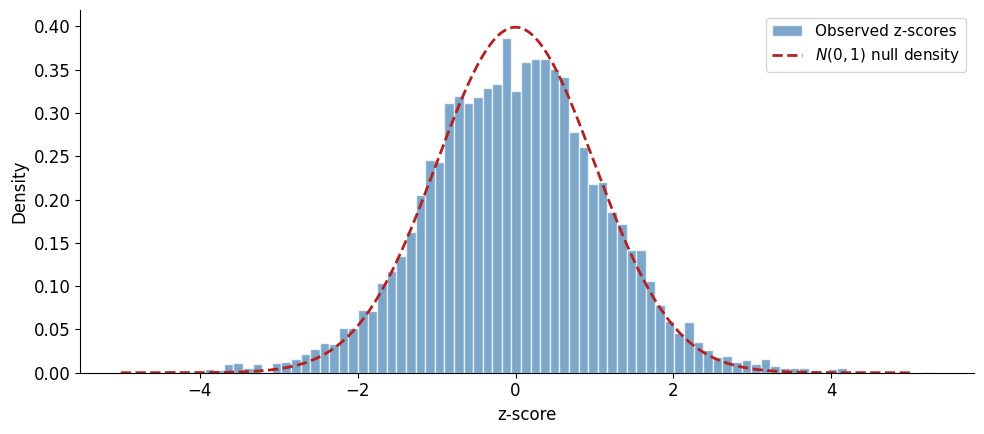

In [37]:
# Load the prostate cancer z-scores (Singh et al. 2002, via Efron)
z_scores = pd.read_csv('prostate_zscores.csv')['zscore'].values
m = len(z_scores)

# Two-sided p-values
p_vals = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))
n_sig = (p_vals < 0.05).sum()
print(f'{m} genes tested')
print(f'{n_sig} of {m} significant at alpha = 0.05')

# Figure 1: Histogram of z-scores with N(0,1) density
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(z_scores, bins=80, density=True, color=COLOR_DATA, edgecolor='white',
        alpha=0.7, label='Observed z-scores')
x = np.linspace(-5, 5, 300)
ax.plot(x, stats.norm.pdf(x), color=COLOR_APPROX, linewidth=2, linestyle='--',
        label='$N(0,1)$ null density')
ax.set_xlabel('z-score')
ax.set_ylabel('Density')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

*__Figure 1.__ Histogram of 6,033 $z$-scores from the prostate cancer gene expression study (blue) with the $N(0,1)$ null density (dashed red). If no genes were truly associated with cancer, the histogram would match the dashed curve. The excess mass in the tails --- genes with $|z| > 2$ or $3$ --- is evidence of real differential expression. But not every gene in the tails is a true discovery.*

The histogram shows a clear excess of large $|z|$-values compared to the $N(0,1)$ null: some genes really are differentially expressed between cancer and control. But with 6,033 tests at $\alpha = 0.05$, we'd expect about $6{,}033 \times 0.05 \approx 302$ false discoveries even if *no* genes were truly associated. Finding 478 significant genes means some are real --- but perhaps a majority of them are noise.

This is the core problem of **multiple testing**: when you run thousands of tests, the chance of false discoveries grows dramatically, and the real signals can be buried among the false ones.

### Setup and Notation

We test $m$ null hypotheses $H_{01}, \ldots, H_{0m}$, each producing a $p$-value $p_i$. Let:

- $\mathcal{R}(X) = \{i : H_{0i} \text{ rejected}\}$ be the set of rejections, with $R = |\mathcal{R}|$
- $\mathcal{H}_0 = \{i : H_{0i} \text{ is true}\}$ be the set of true nulls, with $m_0 = |\mathcal{H}_0|$

In the prostate example: $m = 6{,}033$, each $H_{0i}$ says "gene $i$ has the same expression in cancer and control," and $p_i$ is the two-sided $p$-value from the $z$-score.

If the tests are independent and all nulls are true, then:
$$P(\text{any rejection}) = 1 - (1 - \alpha)^m$$

For $m = 6{,}033$ and $\alpha = 0.05$: $1 - 0.95^{6033}$ is essentially 1. A false discovery is virtually guaranteed!

---

## 2. Familywise Error Rate and Bonferroni

### FWER

The **familywise error rate** is the probability of making *any* false rejection:

$$\text{FWER}_\theta = P_\theta(\text{any false rejection}) = P_\theta(\mathcal{R} \cap \mathcal{H}_0 \neq \emptyset)$$

We want a procedure that controls $\sup_\theta \text{FWER}_\theta \leq \alpha$. This is a strict criterion --- it asks for protection against even a single false rejection, no matter how many true rejections there are.

### Bonferroni Correction

The simplest approach: lower the per-test threshold. **Bonferroni** rejects $H_{0i}$ iff $p_i \leq \alpha/m$.

**Proof.** This is just the union bound:
$$P_\theta(\text{any false rejection}) = P_\theta\Bigl(\bigcup_{i \in \mathcal{H}_0} \{p_i \leq \alpha/m\}\Bigr) \leq \sum_{i \in \mathcal{H}_0} P_\theta(p_i \leq \alpha/m) \leq m_0 \cdot \frac{\alpha}{m} \leq \alpha. \quad \square$$

Key features:
- Works for **any dependence** between the $p$-values --- the union bound makes no independence assumption.
- We use $m$ (total tests) in the denominator, not $m_0$ (true nulls), since we don't know $m_0$. If we knew $m_0$, we could use $\alpha/m_0$ instead.

For the prostate study: the Bonferroni $p$-value threshold is $0.05/6033 \approx 8.3 \times 10^{-6}$, which sounds extremely stringent. But in terms of $z$-scores, this corresponds to rejecting when $|z_i| > z_{\alpha/(2m)} \approx 4.46$ --- it's very hard for *null* genes to have $z$-scores that large, but it's still a threshold for which *non-null* genes with very strong signals can still be detected. In fact, 3 genes do survive (the strongest has $|z| = 5.29$).

In [38]:
# Bonferroni correction for prostate data
bonf_thresh = 0.05 / m
n_bonf = (p_vals < bonf_thresh).sum()
print(f'Bonferroni threshold: 0.05/{m} = {bonf_thresh:.2e}')
print(f'Marginal rejections:   {n_sig} of {m}')
print(f'Bonferroni rejections: {n_bonf} of {m}')

Bonferroni threshold: 0.05/6033 = 8.29e-06
Marginal rejections:   478 of 6033
Bonferroni rejections: 3 of 6033


Bonferroni is devastating: of the 478 genes that were significant at $\alpha = 0.05$, only 3 survive the Bonferroni correction. We went from 478 discoveries to 3. The 475 we lost might include many real effects --- but Bonferroni doesn't care. It guarantees that the chance of *any* false rejection is at most $\alpha = 0.05$, no matter what.

Is this too conservative? Perhaps --- we'll return to this question in Lecture 20 with the false discovery rate.

### Sidak Correction (Independence)

If the $p$-values are **independent**, we can do slightly better. The **Sidak correction** rejects $H_{0i}$ iff $p_i \leq \tilde{\alpha}_m = 1 - (1 - \alpha)^{1/m}$.

**Derivation.**
$$P_\theta(\text{no false rejection}) = \prod_{i \in \mathcal{H}_0} P_\theta(p_i > \tilde{\alpha}_m) = (1 - \tilde{\alpha}_m)^{m_0} \geq (1 - \tilde{\alpha}_m)^m = 1 - \alpha.$$

How much does this improve on Bonferroni?

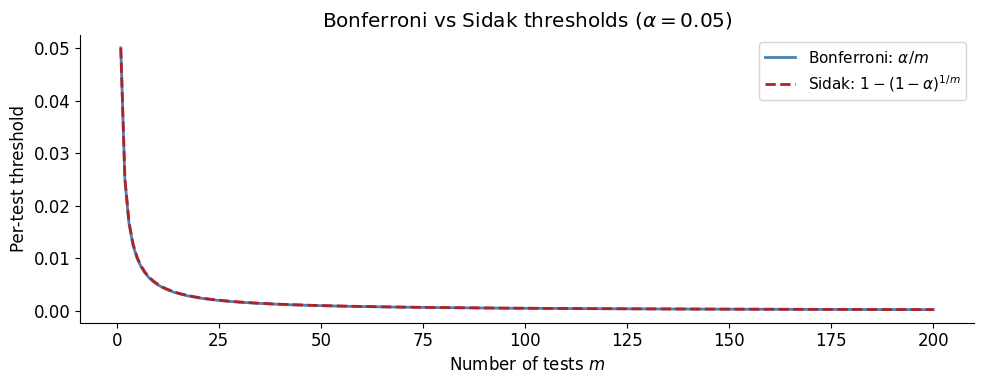

In [39]:
# Figure 1: Bonferroni vs Sidak thresholds
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

m_vals = np.arange(1, 201)
bonf_line = 0.05 / m_vals
sidak_line = 1 - (1 - 0.05) ** (1 / m_vals)

ax.plot(m_vals, bonf_line, color=COLOR_DATA, linewidth=2, label=r'Bonferroni: $\alpha/m$')
ax.plot(m_vals, sidak_line, color=COLOR_APPROX, linewidth=2, linestyle='--',
        label=r'Sidak: $1-(1-\alpha)^{1/m}$')

ax.set_xlabel('Number of tests $m$')
ax.set_ylabel('Per-test threshold')
ax.set_title(r'Bonferroni vs Sidak thresholds ($\alpha = 0.05$)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

*__Figure 2.__ Per-test rejection thresholds for Bonferroni (solid blue) and Sidak (dashed red) as a function of the number of tests $m$. The two curves are nearly indistinguishable: independence barely improves on the union bound.*

**Takeaway.** Independence doesn't help much. Bonferroni's union bound is already nearly tight when the events $\{p_i \leq \alpha/m\}$ have small probability, because these events rarely overlap.

---

## 3. Testing with Dependence: Scheffe's Method

### Motivation: Comparing Hospitals

Suppose we observe quality scores for $d$ hospitals in the Bay Area: $X_i \sim N(\mu_i, 1)$ independently (for simplicity, known equal variance). We might ask:

- "Is hospital $j$ above average?" $\to$ test $H_0: \mu_j - \bar\mu = 0$
- "Is hospital A better than hospital B?" $\to$ test $H_0: \mu_A - \mu_B = 0$
- "Are SF hospitals better on average than Berkeley hospitals?" $\to$ test $H_0: \bar\mu_{\text{SF}} - \bar\mu_{\text{Berk}} = 0$

All of these are tests of $H_{0,\lambda}: \lambda^T \mu = 0$ for different contrast vectors $\lambda$. There are **infinitely many** such contrasts, so Bonferroni is useless ($\alpha/\infty = 0$). But the tests are highly dependent --- they're all functions of the same data vector $X$.

### Scheffe's S-Method

**Setting.** $X \sim N_d(\mu, I_d)$. We want to test $H_{0,\lambda}: \lambda^T \mu = 0$ simultaneously for all unit vectors $\lambda \in S^{d-1}$.  (Why is it ok to restrict our attention to unit vectors?)

For a single $\lambda$: $\lambda^T X \sim N(\lambda^T \mu, 1)$, so we'd reject if $|\lambda^T X| > z_{\alpha/2}$. But we need to come up with a more stringent threshold so that we have FWER control over all $\lambda$.

**Key idea.** Introduce the error vector $Z = X - \mu \sim N_d(0, I_d)$. We don't observe $Z$, but its distribution is known and doesn't depend on $\mu$.

For any $\lambda$ with $\lambda^T \mu = 0$ (i.e., $H_{0,\lambda}$ is true), we have $\lambda^T X = \lambda^T Z$. So:
$$\sup_{\lambda: \lambda^T \mu = 0} |\lambda^T X|^2 = \sup_{\lambda: \lambda^T \mu = 0} |\lambda^T Z|^2 \leq \sup_{\|\lambda\|=1} |\lambda^T Z|^2 = \|Z\|^2 \sim \chi^2_d.$$

**Scheffe's method.** Reject $H_{0,\lambda}$ if $|\lambda^T X|^2 \geq \chi^2_{d,\alpha}$.

This controls FWER at level $\alpha$ over **all** $\lambda$ simultaneously:
$$P_\mu(\text{any true null rejected}) \leq P(\|Z\|^2 \geq \chi^2_{d,\alpha}) = \alpha.$$

### The Geometric View

Since $\|Z\|^2 = \|X - \mu\|^2$, define the confidence region $C(X) = \{\mu : \|X - \mu\|^2 \leq \chi^2_{d,\alpha}\}$ --- a ball of radius $\sqrt{\chi^2_{d,\alpha}}$ centered at $X$.

We reject $H_{0,\lambda}: \lambda^T \mu = 0$ iff the hyperplane $\{\mu: \lambda^T \mu = 0\}$ doesn't intersect $C(X)$.

In other words: we're "deducing" all our test results from a single confidence region. This leads to a general principle.

---

## 4. Deduced Inference and Simultaneous Confidence Intervals

### The Deduction Principle

**General principle.** Given any $1-\alpha$ joint confidence region $C(X)$ for $\theta \in \Theta$, we may freely assume $\theta \in C(X)$ and "deduce" any and all implied conclusions --- without any FWER inflation.

**Proof.** $P_\theta(\text{any deduced conclusion is wrong}) \leq P_\theta(\theta \notin C(X)) \leq \alpha. \quad \square$

This is trivial but powerful! It means we can answer infinitely many questions about $\theta$ without any multiplicity penalty, as long as all our answers are consistent with the confidence region. Scheffe's method is a special case: the $\chi^2$ ball is the confidence region, and each contrast test is a deduction.

### Simultaneous Confidence Intervals

We say $C_1(X), \ldots, C_m(X)$ are **simultaneous $1-\alpha$ confidence intervals** for $g_1(\theta), \ldots, g_m(\theta)$ if:
$$P_\theta\bigl(g_i(\theta) \in C_i(X) \text{ for all } i = 1, \ldots, m\bigr) \geq 1 - \alpha.$$

This is stronger than having each $C_i$ be a marginal $1-\alpha$ CI: the simultaneous guarantee means all $m$ intervals cover at once.

**Bonferroni gives simultaneous CIs.** If each $C_i$ is a marginal $1-\alpha/m$ CI, then by the union bound they are simultaneous $1-\alpha$ CIs:
$$P(\text{any } C_i \text{ fails}) \leq \sum_{i=1}^m P(C_i \text{ fails}) \leq m \cdot \alpha/m = \alpha.$$

But we can often do better using the deduction principle.

### Simultaneous Intervals for the Multivariate Gaussian

**Setting.** $X \sim N_d(\theta, \Sigma)$, $\Sigma$ known with $\Sigma_{ii} = 1$. We want simultaneous CIs for $\theta_1, \ldots, \theta_d$.

Define the error vector $Z = X - \theta \sim N_d(0, \Sigma)$ and the **$\ell_\infty$ norm** ("max norm"):
$$\|Z\|_\infty = \max_{i=1,\ldots,d} |Z_i|.$$

Let $t_\alpha$ be the upper-$\alpha$ quantile of $\|Z\|_\infty$ (depends on $\Sigma$; can compute by simulation).

**Confidence region:** $C(X) = \{\theta : |X_i - \theta_i| \leq t_\alpha \text{ for all } i\}$ --- a rectangular box centered at $X$.

This is the right confidence region for simultaneous CIs because it is built from the $\ell_\infty$ norm of the error vector. The event "$\theta_i \in C_i(X)$ for all $i$" is exactly the event "$\|X - \theta\|_\infty \leq t_\alpha$," so the simultaneous coverage probability equals the confidence level of the box.

**Deduced simultaneous CIs:** $C_i(X) = [X_i - t_\alpha, \, X_i + t_\alpha]$ for each $i$.

These are **exact** simultaneous CIs:
$$P_\theta(\theta_i \in C_i(X) \text{ for all } i) = P(\|Z\|_\infty \leq t_\alpha) = 1 - \alpha.$$

The half-width $t_\alpha$ lies between $z_{\alpha/2}$ (no correction) and $z_{\alpha/(2m)}$ (Bonferroni). When $\Sigma = I_d$, it's close to the Bonferroni/Sidak threshold --- independence doesn't help much, consistent with what we saw above. But when $\Sigma$ has strong positive correlations (the components of $Z$ move together), $t_\alpha$ can be much smaller than the Bonferroni threshold.

---

## 5. Summary

| Concept | Key Idea |
|---------|---------|
| **FWER** | $P(\text{any false rejection}) \leq \alpha$; strict but safe |
| **Bonferroni** | Reject if $p_i \leq \alpha/m$; union bound; works under any dependence |
| **Sidak** | $p_i \leq 1-(1-\alpha)^{1/m}$; requires independence; barely improves on Bonferroni |
| **Scheffe** | Controls FWER over infinitely many contrasts using $\chi^2$ confidence ball |
| **Deduction principle** | Any conclusion from a $1-\alpha$ confidence region is FWER-controlled |
| **Simultaneous CIs** | $P(\theta_j \in C_j \text{ for all } j) \geq 1-\alpha$; can be tighter than Bonferroni when tests are correlated |

**Next time (Lecture 20).** FWER control is conservative: it treats one false rejection among many valid ones as catastrophic. For the prostate data, Bonferroni reduced 478 discoveries to just 3 --- we lost almost everything. In large-scale screening, we might prefer to tolerate a small *proportion* of false discoveries rather than missing nearly all the real effects. We'll define the **false discovery rate (FDR)** and the **Benjamini-Hochberg procedure**, which will recover many more of the prostate cancer genes that Bonferroni discarded.